In [ ]:
# mengimpor pustaka pandas dan memberi alias pd. pandas adalah pustaka yg digunakan untuk manipulasi data dan analissis, tertutama dengan struktur data seperti dataframe
import pandas as pd
#Numpy adalah pustaka yg digunakan untuk komputasi ilmiah dgn python. Ini mendukung array multidimensi dan berbagai fungsi matematika tingkat lanjut
import numpy as np
#pickle digunakan untuk menyimpan objek python ke dalam file atau memuatnya kkembali dari file
import pickle
#matplotlib adalah pustaka untuk membuat visualisasi data, seprti grafik dan plot
import matplotlib.pyplot as plt
#untuk menghubungkan google colab ddengan google drive
from google.colab import drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_dir = '/content/drive/MyDrive/fixed/'

# Load dataset
scraped_df_csv = pd.read_csv(base_dir+'dataset_scrapping.csv')
loan_df_csv = pd.read_csv(base_dir+'dataset-pinjam2.csv')

#conversi jika data dalam bentuk json
scraped_df_json = scraped_df_csv.to_json(orient="records")
loan_df_json = loan_df_csv.to_json(orient="records")

scraped_df = pd.read_json(scraped_df_json)
loan_df = pd.read_json(loan_df_json)

<ipython-input-3-6b590630793b>:11: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  scraped_df = pd.read_json(scraped_df_json)
<ipython-input-3-6b590630793b>:12: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  loan_df = pd.read_json(loan_df_json)


Menampilkan seluruh hasil rekomendasi berasal dari dataset loan

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

#fungsi ini menerima dua dataframe
def book_recommendations(loan_df, scraped_df):

    # creating a content profile
    #mengisi nilai NaN dengan string kosong untuk mencegah masalah saat menggabungkan kolom
    loan_df['judul'] = loan_df['judul'].fillna('')
    loan_df['kategori'] = loan_df['kategori'].fillna('')
    loan_df['penulis'] = loan_df['penulis'].fillna('')

    scraped_df['judul'] = scraped_df['judul'].fillna('')
    scraped_df['kategori'] = scraped_df['kategori'].fillna('')
    scraped_df['penulis'] = scraped_df['penulis'].fillna('')

    # Menggabungkan kolom menjadi satu kolom 'content'
    loan_df['content'] = loan_df['judul'] + ' ' + loan_df['kategori'] + ' ' + loan_df['penulis'].astype(str)
    scraped_df['content'] = scraped_df['judul'] + ' ' + scraped_df['kategori'] + ' ' + scraped_df['penulis'].astype(str)

    # Menghitung TF-IDF
    tfidf = TfidfVectorizer(stop_words='english')
    tfidf_matrix_loan = tfidf.fit_transform(loan_df['content'])
    tfidf_matrix_scraped = tfidf.transform(scraped_df['content'])
    #menghitung kesamaan antara vektor tf-idf dari scraped dan loan, menghasilkan matriks kesamaan kosinus
    cosine_sim = cosine_similarity(tfidf_matrix_scraped, tfidf_matrix_loan)

    #calculate hybrid CBF & CF
    #fungsi ini menghitung skor hybrid untuk setiap buku yg di scrape, berdasarkan kesamaan konten dan popularitas buku
    def calculate_hybrid_scores(cosine_sim, loan_df, scraped_df, top_n=5):
      hybrid_scores = []
      for idx, row in enumerate(cosine_sim):
          #indeks buku dengan kesamaan tertinggi
          top_books_indices = row.argsort()[-top_n:][::-1]
          #skor kesamaan dari buku-buku tersebut
          top_books_scores = row[top_books_indices]
          #jumlah peminjam dari buku-buku tersebut
          top_books_peminjam = loan_df.iloc[top_books_indices]['total_peminjam'].values
          #rating dari buku-buku tersebut
          top_books_rating = scraped_df.loc[idx, 'rating']

          #menghitung skor hybrid
          score = ((top_books_scores.mean() * top_books_peminjam.mean()) + top_books_rating) / 2
          hybrid_scores.append(score)

      return hybrid_scores


    #skor hybrid ditambahkan ke scraped_Df
    #buku dengan skor hybrid diatas treshold do filter dan diurutkan berdasarkan skor hybrid
    hybrid_scores = calculate_hybrid_scores(cosine_sim, loan_df, scraped_df)
    scraped_df['hybrid_score'] = hybrid_scores

    treshold =15
    recommended_books_above_threshold = scraped_df[scraped_df['hybrid_score'] >= treshold]
    recommended_books_sorted = recommended_books_above_threshold.sort_values(by='hybrid_score', ascending=False)

    book_indices = recommended_books_sorted.index
    cosine_scores = []
    for idx in book_indices:
        cosine_values = cosine_sim[idx]
        cosine_score = cosine_values.mean()
        cosine_scores.append(cosine_score)

    recommended_books_copy = recommended_books_sorted.copy()
    recommended_books_copy['cosine_score'] = cosine_scores

    return recommended_books_copy

Function untuk mencari kategori popular:

fungsi ini bertujuan untuk menghitung dan mengurutkan kategori buku berdasarkan total jumlah peminjam. Fungsi ini kemudian mengembalikan daftar kategori teratas berdasarkan jumlah peminjam, dengan opsi untuk membatasi jumlah kategori yg di tampilkan.

In [ ]:
def top_categories(limit=0):
    category_stats = loan_df.groupby('kategori')['total_peminjam'].sum().reset_index()

    sorted_categories = category_stats.sort_values(by='total_peminjam', ascending=False)

    if(limit > 0):
        return sorted_categories.head(limit)
    else:
        return sorted_categories

Statistik buku:


,kategori,total_peminjam
6,Akuntansi Lanjutan,1158
2,Akuntansi,799
8,Audit Keuangan,383
47,Manajemen Pemasaran,376
50,Manajemen Strategi,272
15,Ekonomi Keuangan,224
7,Akuntansi Manajerial,200
43,Manajemen Keuangan,187
72,Sistem Informasi Akuntansi,176
27,Ilmu Komputer,150


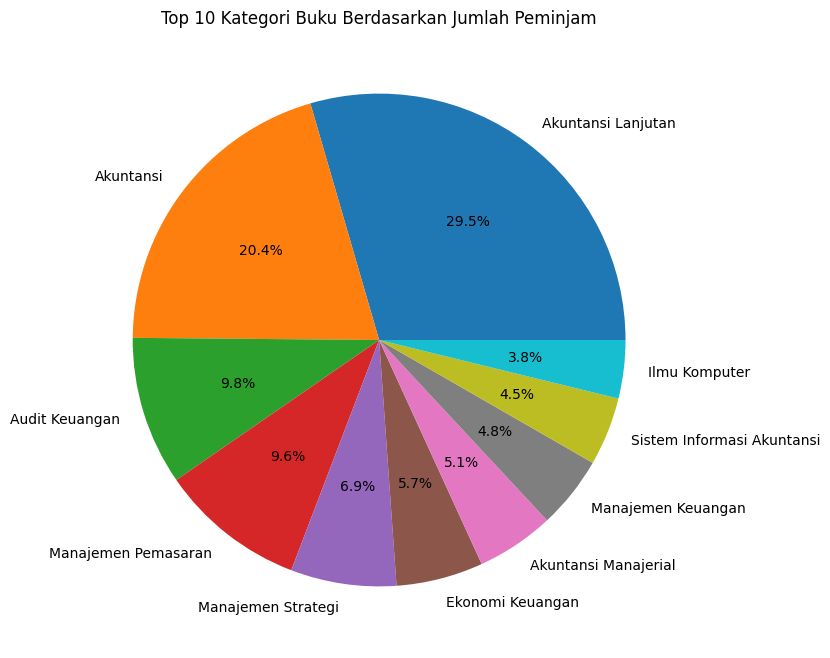

In [ ]:
top_category = top_categories(10);
display(top_category)

plt.figure(figsize=(8, 8))
plt.pie(top_category['total_peminjam'], labels=top_category['kategori'], autopct='%1.1f%%')
plt.title('Top 10 Kategori Buku Berdasarkan Jumlah Peminjam')
plt.show()


**#Mencari Buku Rekomendasi**

1. Mencari berdasarkan judul dari buku peminjaman (loan):

In [ ]:
# judul_pencarian = loan_df.iloc[10]['judul']

judul_pencarian = "Pemasaran Jasa : Manusia, Teknologi, Strategi Perspektif Indonesia Jilid 1 Ed.7"
index_buku = loan_df[loan_df['judul'] == judul_pencarian].index[0]


recommendations = book_recommendations(loan_df, scraped_df)
result = recommendations[['judul', 'kategori', 'penulis', 'rating', 'hybrid_score', 'cosine_score']]
print("Buku Rekomendasi untuk '{}':".format(judul_pencarian))
display(result)

Buku Rekomendasi untuk 'Pemasaran Jasa : Manusia, Teknologi, Strategi Perspektif Indonesia Jilid 1 Ed.7':


,judul,kategori,penulis,rating,hybrid_score,cosine_score
2183,Akuntansi Keuangan Lanjutan Perspektif Indones...,Akuntansi Lanjutan,Richard E Baker Dkk,5.00,35.054753,0.046443
1573,Manajemen Pemasaran - Jilid 2,Manajemen Pemasaran,"Philip Kotler,Kevin Lane Keller",4.38,30.623985,0.034708
1861,Manajemen Pemasaran - Jilid 2,Pemasaran,"Philip Kotler, Kevin Lane Keller",4.38,30.467867,0.027917
1860,Manajemen Pemasaran - Jilid 1,Pemasaran,"Philip Kotler, Kevin Lane Keller",4.25,30.402867,0.027917
2216,Pengantar Akuntansi 2 Berbasis Ifrs (E2),Akuntansi Lanjutan,"WEYGANDT, KIESO",4.90,27.558629,0.032756
2226,Pengantar Akuntansi 1 Berbasis Ifrs (E2),Akuntansi Lanjutan,"WEYGANDT, KIESO",4.00,27.108629,0.032756
1567,Manajemen Pemasaran - Jilid 1,Manajemen Pemasaran,Philip Kotler,4.25,23.605663,0.042588
1712,Manajemen Pemasaran,Pemasaran,Philip Kotler,4.06,22.927190,0.031840
2176,Akuntansi Keuangan Menengah Berbasis Psak Buku 2,Akuntansi Lanjutan,Dwi Martani Dkk,4.60,19.976662,0.037101
2173,Akuntansi Keuangan Menengah Berbasis Psak Ed 2...,Akuntansi Lanjutan,Dwi Martani Dkk,4.70,19.899188,0.040510


2. Mencari buku berdasarkan kategori:

kode ini melakukan beberapa langkah untuk mencari buku -buku erdasarkan kategori yg di inoutkan dan kemudian menghasilkan rekomendasi buku dalam kategori tersebut

In [ ]:
import pandas as pd

# Fungsi untuk mencari kategori berdasarkan judul
#fungsi ini menerima 4 paramete
def find_category_by_title(top_categories_df, loan_df, input_category_title, limit=10):
    #mencari baris dalam top_categories yg memiliki nama kategori sesuai dengan input_category
    selected_category = top_categories_df[top_categories_df['kategori'] == input_category_title]

    #jika kategori ditemuukan atau tdk kosong maka:
    #selected_category_name diambil sebagai nama kategori yg ditemukan
    #buku-buku yg termasuk dalam kategori ini diambil dari loan_Df
    if not selected_category.empty:
        selected_category_name = selected_category.iloc[0]['kategori']

        top_category_books = loan_df[loan_df['kategori'] == selected_category_name]

        #menampilkan dan mengembalikan hasil
        print("Selected Category:", selected_category_name)
        print("Top Category Books:")
        top_book_by_category = top_category_books[['judul', 'tahun_terbit', 'kategori','penulis', 'total_peminjam']]
        results = top_book_by_category.head(limit)
        return results
    else:
        return None


# Input judul kategori
input_category_title = "Akuntansi"
get_book_loan = find_category_by_title(top_categories(10), loan_df, input_category_title)
print("Daftar top 10 buku kategori "+ input_category_title + ":")
display(get_book_loan)
print("Daftar buku rekomendasi kategori "+ input_category_title + ":")
result_book_recommendations = book_recommendations(get_book_loan, scraped_df)
display(result_book_recommendations)

# Simpan hasil ke dalam file Excel
file_path = 'rekomendasi_buku_kategori_{}.xlsx'.format(input_category_title)
result_book_recommendations.to_excel(file_path, index=False)

print("Hasil rekomendasi telah disimpan dalam file:", file_path)


Selected Category: Akuntansi
Top Category Books:
Daftar top 10 buku kategori Akuntansi:


,judul,tahun_terbit,kategori,penulis,total_peminjam
3,Pengantar Akuntansi 1 Berbasis IFRS Edisi 2,2018,Akuntansi,"Donald E., Kieso, Paul D. Kimmel, WEYGANDT,Je...",147
6,Akuntansi Perpajakan Berbasis ETAP Edisi 3,2014,Akuntansi,"Estralita Trisnawati, Sukrisno Agoes,Sukrisno...",110
8,Pengantar Akuntansi Adaptasi Indonesia Edisi 25,2015,Akuntansi,"Carl S. Warren, James M. Reeve, Jonathan E. D...",93
17,Financial Accounting IFRS Ed. 1Ed.,2011,Akuntansi,"KIMMEL, WEYGANDT,Jerry J.,Paul D.,WEYGANDT",56
18,Pengantar Akuntansi 1 Edisi 4 Adaptasi Indone...,2017,Akuntansi,"Amir Abadi, Carl S., JUSUF, Jonathan E. Ducha...",45
31,Sistem Akuntansi Edisi 4,2016,Akuntansi,"MULYADI,MULYADI",32
33,Akutansi Keuangan Berdasarkan SAK Buku 1,2012,Akuntansi,"KARTIKAHADI, SINAGA,Hans,KARTIKAHADI,Rosita Uli",28
35,Perpajakan Buku 1 Ed.8,2014,Akuntansi,"RESMI,RESMI,Siti",28
36,Pengantar Akuntansi 2 Berbasis IFRS Edisi 2 (F...,2018,Akuntansi,"Donal E, Jerry J, Kieso, Kimmel, Paul D., Wey...",27
42,Pengantar Akuntansi 1 Edisi 2,2016,Akuntansi,"Agus Purwaji, H. Murtanto, WIBOWO,WIBOWO",24


Daftar buku rekomendasi kategori Akuntansi:


,judul,tahun_terbit,kategori,penulis,rating,content,hybrid_score,cosine_score
2216,Pengantar Akuntansi 2 Berbasis Ifrs (E2),2018,Akuntansi Lanjutan,"WEYGANDT, KIESO",4.9,Pengantar Akuntansi 2 Berbasis Ifrs (E2) Akunt...,18.232275,0.265215
2226,Pengantar Akuntansi 1 Berbasis Ifrs (E2),2010,Akuntansi Lanjutan,"WEYGANDT, KIESO",4.0,Pengantar Akuntansi 1 Berbasis Ifrs (E2) Akunt...,17.782275,0.265215


Hasil rekomendasi telah disimpan dalam file: rekomendasi_buku_kategori_Akuntansi.xlsx


In [ ]:
# New function to find recommendations by book title
def find_recommendations_by_title(loan_df, scraped_df, book_title):
    book_data = loan_df[loan_df['judul'] == book_title]

    if book_data.empty:
        print("Book title not found in loan_df.")
        return None

    print("Selected Book Title:", book_title)
    print("Book Details:")
    display(book_data)

    recommendations = book_recommendations(book_data, scraped_df)
    return recommendations

input_book_title = "Akuntansi Keuangan Menengah Berbasis PSAK-PSAK Konvergensi IFRS Buku 2"
result_book_recommendations_by_title = find_recommendations_by_title(loan_df, scraped_df, input_book_title)
if result_book_recommendations_by_title is not None:
    print("Rekomendasi untuk judul buku '" + input_book_title + "':")
    display(result_book_recommendations_by_title)

Selected Book Title: Akuntansi Keuangan Menengah Berbasis PSAK-PSAK Konvergensi IFRS Buku 2
Book Details:


,judul,tahun_terbit,kategori,penulis,total_peminjam,content
12,Akuntansi Keuangan Menengah Berbasis PSAK-PSAK...,2015,Akuntansi Lanjutan,"Dwi Martani, Ratna Wardhani, Sylvia Veronica ...",87,Akuntansi Keuangan Menengah Berbasis PSAK-PSAK...


<ipython-input-4-933f6d54672f>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_df['judul'] = loan_df['judul'].fillna('')
<ipython-input-4-933f6d54672f>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_df['kategori'] = loan_df['kategori'].fillna('')
<ipython-input-4-933f6d54672f>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pa

Rekomendasi untuk judul buku 'Akuntansi Keuangan Menengah Berbasis PSAK-PSAK Konvergensi IFRS Buku 2':


,judul,tahun_terbit,kategori,penulis,rating,content,hybrid_score,cosine_score
2173,Akuntansi Keuangan Menengah Berbasis Psak Ed 2...,2024,Akuntansi Lanjutan,Dwi Martani Dkk,4.7,Akuntansi Keuangan Menengah Berbasis Psak Ed 2...,37.946793,0.818317
2176,Akuntansi Keuangan Menengah Berbasis Psak Buku 2,2018,Akuntansi Lanjutan,Dwi Martani Dkk,4.6,Akuntansi Keuangan Menengah Berbasis Psak Buku...,37.896793,0.818317
2175,Akuntansi Keuangan Lanjutan 1 Berbasis PSAK,2016,Akuntansi Lanjutan,"Dwi Martani,taufik Hidayat,agustin Sn,teguh I",4.3,Akuntansi Keuangan Lanjutan 1 Berbasis PSAK Ak...,34.070273,0.733799
2023,Akuntansi Suatu Pengantar-Berbasis PSAK Buku 2,2018,Akuntansi,PPA FEB UI,5.0,Akuntansi Suatu Pengantar-Berbasis PSAK Buku 2...,27.357143,0.571429
2215,Akuntansi Suatu Pengantar Berbasis PSAK Buku 1,2017,Akuntansi,Catur Sasongko Dkk,4.5,Akuntansi Suatu Pengantar Berbasis PSAK Buku 1...,27.107143,0.571429
...,...,...,...,...,...,...,...,...
1339,Sosok 33 Akuntan Indonesia: Sejumlah Masalah A...,2018,Akuntansi,Ohiao Halawa,0.0,Sosok 33 Akuntan Indonesia: Sejumlah Masalah A...,16.441455,0.377964
1340,Trik Praktis Excel untuk Akuntansi,2014,Akuntansi,Jubilee Enterprise,0.0,Trik Praktis Excel untuk Akuntansi Akuntansi J...,16.441455,0.377964
1341,Akuntansi Dasar 1 dan 2 (Indonesian Edition) b...,2018,Akuntansi,S.E. M.Si Herry,0.0,Akuntansi Dasar 1 dan 2 (Indonesian Edition) b...,16.441455,0.377964
10,Metodologi Penelitian Manajemen,2022,Metodelogi Penelitian,"Esti Dwi Rahmawati SE.,MM.",0.0,Metodologi Penelitian Manajemen Metodelogi Pen...,16.441455,0.377964


In [ ]:
!pip install pyngrok

In [ ]:
!pip install flask-cors

In [ ]:
from flask import Flask, jsonify, request
from flask_cors import CORS
from pyngrok import ngrok


# Masukkan authtoken ngrok Anda di sini
ngrok.set_auth_token('2h86pgSmGloadWDb7UKRRiRw9Qv_72ENHNgCpkGp3cy89B29H')

app = Flask(__name__)
CORS(app)

@app.route('/recommend', methods=['POST'])
def get_recommendations_by_title():
    data = request.get_json()
    input_book_title = data.get('input_book_title')

    if not input_book_title:
        return jsonify({'message': 'Book title not provided'}), 400


    recommendations = find_recommendations_by_title(loan_df_csv, scraped_df_csv, input_book_title)

    if recommendations is not None:
        result = recommendations[['judul', 'kategori', 'penulis', 'rating', 'hybrid_score', 'cosine_score']]
        return jsonify(result.to_dict(orient='records'))
    else:
        return jsonify({'message': 'Book not found or no recommendations available'})

@app.route('/find_books_and_recommendations_by_category', methods=['POST'])
def find_books_and_recommendations_by_category():
    data = request.get_json()
    input_category_title = data.get('category_title')

    base_dir = '/content/drive/MyDrive/bab4/bab 4 - book recommendation/yg ini/baruu/raiyana/'
    loan_df = pd.read_csv(base_dir + 'dataset-pinjam2.csv')
    scraped_df = pd.read_csv(base_dir + 'dataset_scrapping.csv')

    top_categories_df = top_categories()
    top_books = find_category_by_title(top_categories_df, loan_df, input_category_title)

    if top_books is not None:
        recommendations = book_recommendations(top_books, scraped_df)
        return jsonify({
            'popular_books': top_books.to_dict(orient='records'),
            'recommendations': recommendations[['judul', 'kategori', 'penulis', 'rating', 'hybrid_score', 'cosine_score']].to_dict(orient='records')
        })
    else:
        return jsonify({'message': 'Category not found'})


@app.route('/top_categories', methods=['GET'])
def get_top_categories():
    limit = int(request.args.get('limit', 10))
    categories = top_categories(limit)
    return jsonify(categories.to_dict(orient='records'))

@app.route('/loan_data', methods=['GET'])
def get_loan_data():
    # Load dataset
    base_dir = '/content/drive/MyDrive/bab4/bab 4 - book recommendation/yg ini/baruu/raiyana/'
    loan_df_csv = pd.read_csv(base_dir + 'dataset-pinjam2.csv')

    # Convert loan_df data to JSON
    loan_data_dict = loan_df_csv.to_dict(orient="records")
    return jsonify(loan_data_dict)

# Run ngrok to make your Flask app accessible via a public URL
ngrok_tunnel = ngrok.connect(5000)
print('Public URL:', ngrok_tunnel.public_url)

if __name__ == '__main__':
    app.run()

Public URL: https://bc1f-34-123-188-130.ngrok-free.app
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
